# ============================================================
# PIPELINE EUREKA
# ============================================================
#
# O pipeline foi desenvolvido para ser facilmente integrado com
# aplicações externas, recebendo um DataFrame com as colunas:
#
#     Data | Valor
#
# O código é composto por:
#   1. Preparação e validação dos dados de entrada;
#   2. Criação das features para treino e inferência;
#   3. Treino do modelo Autoformer;
#   4. Geração de previsões futuras através de inferência;
#   5. (Opcional) Guardar e carregar o modelo treinado.
#
# Funções:
#
#     treinar_modelo(dados_historico)
#     inferencia_modelo(modelo, dados_historico)
# ============================================================

In [ ]:
import math
import time
import copy
import warnings
from typing import Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


# ============================================================
# CONFIGURAÇÕES
# ============================================================
CONFIG = {
    "date_col": "Data",
    "value_col": "Valor",

    "lags": [1, 2, 3, 5, 7, 14, 30],
    "dias_prever_default": 30,

    "batch_size": 256,
    "num_epochs": 1000,
    "patience": 15,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "clip_norm": 1.0,
    "warmup_fraction": 0.05,

    "node_emb": 128,
    "attn_heads": 8,
    "kernel_size": 13,
    "auto_num_layers": 2,
    "cat_emb_dim": 8,
    "dropout": 0.20,

    "val_ratio": 0.2,
    "seed": 1124,
}


def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================
# INPUT
# ============================================================
def preparar_input(
    dados: pd.DataFrame,
    date_col: str = "Data",
    value_col: str = "Valor"
) -> pd.DataFrame:
    """
    Recebe DataFrame externo com colunas Data/Valor.
    Mantém os nomes Data e Valor.
    Não lê ficheiros. O agente é que carrega o CSV/XLSX.
    """
    if not isinstance(dados, pd.DataFrame):
        raise TypeError("dados deve ser um pandas DataFrame.")

    if date_col not in dados.columns:
        raise ValueError(f"Coluna de data não encontrada: {date_col}")

    if value_col not in dados.columns:
        raise ValueError(f"Coluna de valor não encontrada: {value_col}")

    df = dados[[date_col, value_col]].copy()

    # Garantir nomes oficiais do pipeline
    if date_col != "Data":
        df = df.rename(columns={date_col: "Data"})
    if value_col != "Valor":
        df = df.rename(columns={value_col: "Valor"})

    df["Data"] = pd.to_datetime(df["Data"])
    df["Valor"] = pd.to_numeric(df["Valor"], errors="coerce")

    df = df.dropna(subset=["Data", "Valor"])
    df = df.sort_values("Data").reset_index(drop=True)

    # Se houver várias linhas na mesma data, agrega por soma
    df = df.groupby("Data", as_index=False)["Valor"].sum()

    # Garantir frequência diária
    full_dates = pd.date_range(df["Data"].min(), df["Data"].max(), freq="D")
    df = df.set_index("Data").reindex(full_dates)
    df.index.name = "Data"
    df["Valor"] = df["Valor"].fillna(0).clip(lower=0)
    df = df.reset_index()

    # IDs fictícios para manter compatibilidade com o modelo atual
    df["item_id"] = "single_item"
    df["store_id"] = "single_store"
    df["item_id_idx"] = 0
    df["store_id_idx"] = 0
    df["item_store_id"] = "single_item_single_store"
    df["node_idx"] = 0

    return df


# ============================================================
# FEATURES DE CALENDÁRIO
# ============================================================
def get_season(date: pd.Timestamp) -> str:
    month = date.month
    day = date.day

    if (month == 12 and day >= 21) or month in [1, 2] or (month == 3 and day < 20):
        return "winter"
    elif (month == 3 and day >= 20) or month in [4, 5] or (month == 6 and day < 21):
        return "spring"
    elif (month == 6 and day >= 21) or month in [7, 8] or (month == 9 and day < 23):
        return "summer"
    else:
        return "autumn"


def calculate_payday_distance(date: pd.Timestamp) -> int:
    day = date.day
    last_day = (date + pd.offsets.MonthEnd(0)).day
    return min(abs(day - 15), abs(day - last_day))


def calculate_christmas_effect(date: pd.Timestamp) -> float:
    year = date.year
    christmases = [
        pd.Timestamp(year=year - 1, month=12, day=25),
        pd.Timestamp(year=year, month=12, day=25),
        pd.Timestamp(year=year + 1, month=12, day=25),
    ]
    differences = [(date - christmas).days for christmas in christmases]
    d = min(differences, key=lambda x: abs(x))
    dist = abs(d)
    return float(np.exp(-0.1 * dist) if d < 0 else np.exp(-0.3 * dist))


def calculate_simple_holiday_proximity(date: pd.Timestamp) -> float:
    year = date.year
    fixed_dates = [
        pd.Timestamp(year=year, month=1, day=1),
        pd.Timestamp(year=year, month=5, day=1),
        pd.Timestamp(year=year, month=12, day=25),
        pd.Timestamp(year=year, month=12, day=31),
    ]
    distances = [abs((date - d).days) for d in fixed_dates]
    return float(np.exp(-min(distances) / 7))


def calculate_school_break_proximity(date: pd.Timestamp) -> float:
    year = date.year
    intervals = [
        (pd.Timestamp(year=year, month=7, day=15), pd.Timestamp(year=year, month=9, day=15)),
        (pd.Timestamp(year=year, month=12, day=15), pd.Timestamp(year=year + 1, month=1, day=10)),
        (pd.Timestamp(year=year, month=3, day=15), pd.Timestamp(year=year, month=4, day=15)),
    ]

    distances = []
    for start, end in intervals:
        if start <= date <= end:
            distances.append(0)
        else:
            distances.append(min(abs((date - start).days), abs((date - end).days)))

    return float(np.exp(-min(distances) / 7))


def calculate_festive_proximity(date: pd.Timestamp) -> float:
    year = date.year
    festive_dates = []
    festive_dates.extend(pd.date_range(f"{year}-12-20", f"{year}-12-26"))
    festive_dates.extend(pd.date_range(f"{year}-12-31", f"{year + 1}-01-02"))
    festive_dates.extend(pd.date_range(f"{year}-04-01", f"{year}-04-10"))

    distances = [abs((date - d).days) for d in festive_dates]
    return float(np.exp(-min(distances) / 7))


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Data"] = pd.to_datetime(df["Data"])

    df["day_of_week"] = df["Data"].dt.dayofweek
    df["month"] = df["Data"].dt.month
    df["day_of_year"] = df["Data"].dt.dayofyear
    df["week"] = df["Data"].dt.isocalendar().week.astype(int)

    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

    df["weekend_proximity"] = df["day_of_week"].apply(
        lambda x: 0.75 * np.exp(-0.5 * abs(5 - x))
    )

    df["payday_proximity"] = df["Data"].apply(calculate_payday_distance)
    df["payday_proximity"] = df["payday_proximity"].apply(lambda x: np.exp(-0.1 * x))

    df["christmas_effect"] = df["Data"].apply(calculate_christmas_effect)
    df["holiday_proximity"] = df["Data"].apply(calculate_simple_holiday_proximity)
    df["school_break_proximity"] = df["Data"].apply(calculate_school_break_proximity)
    df["festive_proximity"] = df["Data"].apply(calculate_festive_proximity)

    df["season"] = df["Data"].apply(get_season)
    df = pd.get_dummies(df, columns=["season"], dtype=int)

    for col in ["season_autumn", "season_spring", "season_summer", "season_winter"]:
        if col not in df.columns:
            df[col] = 0

    return df


# ============================================================
# LISTAS DE FEATURES
# ============================================================
CATEGORICAL_FEATURES = [
    "season_autumn",
    "season_spring",
    "season_summer",
    "season_winter",
]

LAGS = CONFIG["lags"]
LAG_FEATURES = [f"Lag-{lag}" for lag in LAGS]

NUMERIC_FEATURES_BASE = [
    "holiday_proximity",
    "school_break_proximity",
    "festive_proximity",
    "day_of_week",
    "month",
    "day_of_year",
    "week",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "weekend_proximity",
    "payday_proximity",
    "christmas_effect",
]

NUMERIC_FEATURES = NUMERIC_FEATURES_BASE + LAG_FEATURES

FEATURES_TO_NORMALIZE = [
    "holiday_proximity",
    "school_break_proximity",
    "festive_proximity",
    "weekend_proximity",
    "payday_proximity",
    "christmas_effect",
] + LAG_FEATURES


# ============================================================
# FEATURES PARA TREINO
# ============================================================
def add_lag_features_train(df: pd.DataFrame, lags=LAGS) -> pd.DataFrame:
    """
    Cria lags de treino usando apenas valores passados reais.
    """
    df = df.copy()
    df = df.sort_values(["item_id", "store_id", "Data"]).reset_index(drop=True)

    for lag in lags:
        df[f"Lag-{lag}"] = df.groupby(["item_id", "store_id"])["Valor"].shift(lag)

    lag_cols = [f"Lag-{lag}" for lag in lags]
    df[lag_cols] = df[lag_cols].fillna(0).clip(lower=0)

    return df


def criar_features_treino(dados_historico: pd.DataFrame) -> pd.DataFrame:
    """
    Função para criação de features de treino.
    Entrada: DataFrame Data/Valor.
    Saída: DataFrame com features completas.
    """
    df = preparar_input(
        dados_historico,
        date_col=CONFIG["date_col"],
        value_col=CONFIG["value_col"],
    )

    df = add_calendar_features(df)
    df = add_lag_features_train(df, lags=LAGS)

    for col in CATEGORICAL_FEATURES:
        if col not in df.columns:
            df[col] = 0
        df[col] = df[col].fillna(0).astype(int)

    for col in NUMERIC_FEATURES:
        if col not in df.columns:
            df[col] = 0
        df[col] = df[col].fillna(0).astype(float)

    df["Valor"] = df["Valor"].fillna(0).clip(lower=0).astype(float)

    return df


# ============================================================
# FEATURES PARA INFERÊNCIA
# ============================================================
def criar_features_inferencia_uma_data(
    historico_atualizado: pd.DataFrame,
    data_prever: pd.Timestamp,
    scaler: StandardScaler,
) -> pd.DataFrame:
    """
    Cria features para uma única data futura.
    Usa apenas histórico conhecido + previsões anteriores já adicionadas ao histórico.
    """
    hist = historico_atualizado.copy()
    hist["Data"] = pd.to_datetime(hist["Data"]).dt.normalize()

    data_prever = pd.to_datetime(data_prever).normalize()

    row = pd.DataFrame({
        "Data": [data_prever],
        "Valor": [np.nan],
        "item_id": ["single_item"],
        "store_id": ["single_store"],
        "item_id_idx": [0],
        "store_id_idx": [0],
        "item_store_id": ["single_item_single_store"],
        "node_idx": [0],
    })

    row = add_calendar_features(row)

    for lag in LAGS:
        lag_day = data_prever - pd.Timedelta(days=lag)
        lag_value = hist.loc[hist["Data"] == lag_day, "Valor"]
        row[f"Lag-{lag}"] = float(lag_value.iloc[-1]) if len(lag_value) > 0 else 0.0

    for col in CATEGORICAL_FEATURES:
        if col not in row.columns:
            row[col] = 0
        row[col] = row[col].fillna(0).astype(int)

    for col in NUMERIC_FEATURES:
        if col not in row.columns:
            row[col] = 0
        row[col] = row[col].fillna(0).astype(float)

    row[FEATURES_TO_NORMALIZE] = scaler.transform(row[FEATURES_TO_NORMALIZE])

    return row


def criar_features_inferencia(
    dados_historico: pd.DataFrame,
    model_artifact: Dict,
    dias_prever: int = 30,
) -> pd.DataFrame:
    """
    Função para criação de features de inferência.
    Cria as linhas futuras iniciais. A atualização recursiva com previsões anteriores
    acontece em inferencia_modelo().
    """
    df_hist = preparar_input(
        dados_historico,
        date_col=model_artifact["date_col"],
        value_col=model_artifact["value_col"],
    )

    scaler = model_artifact["scaler"]
    last_date = df_hist["Data"].max()

    rows = []
    hist = df_hist.copy()

    for step in range(dias_prever):
        data_prever = last_date + pd.Timedelta(days=step + 1)
        row = criar_features_inferencia_uma_data(hist, data_prever, scaler)
        rows.append(row)

        hist = pd.concat([
            hist,
            pd.DataFrame({
                "Data": [data_prever],
                "Valor": [np.nan],
                "item_id": ["single_item"],
                "store_id": ["single_store"],
                "item_id_idx": [0],
                "store_id_idx": [0],
                "item_store_id": ["single_item_single_store"],
                "node_idx": [0],
            })
        ], ignore_index=True)

    return pd.concat(rows, ignore_index=True)


# ============================================================
# MODELO
# ============================================================
class Time2Vec(nn.Module):
    def __init__(self, d_model, num_frequencies=20):
        super().__init__()
        self.linear_weight = nn.Parameter(torch.randn(1, 1, d_model // 2))
        self.linear_bias = nn.Parameter(torch.randn(1, 1, d_model // 2))
        self.periodic_weight = nn.Parameter(torch.randn(1, 1, num_frequencies))
        self.periodic_bias = nn.Parameter(torch.randn(1, 1, num_frequencies))
        self.out_projection = nn.Linear(d_model // 2 + num_frequencies, d_model)

    def forward(self, x):
        b, L, _ = x.size()
        t = torch.arange(L, dtype=torch.float, device=x.device).view(1, L, 1).expand(b, L, 1)
        linear = t * self.linear_weight + self.linear_bias
        periodic = torch.sin(t * self.periodic_weight + self.periodic_bias)
        te = torch.cat([linear, periodic], dim=-1)
        return x + self.out_projection(te)


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=kernel_size // 2)

    def forward(self, x):
        if x.size(1) < self.kernel_size:
            pad = self.kernel_size - x.size(1)
            x_padded = F.pad(x, (0, 0, pad, pad), mode="replicate")
        else:
            x_padded = x

        trend = self.avg(x_padded.permute(0, 2, 1)).permute(0, 2, 1)

        if x.size(1) < self.kernel_size:
            trend = trend[:, :x.size(1), :]

        return x - trend, trend


class AutoCorrelation(nn.Module):
    def __init__(self, d_model, n_heads, top_k=5, dropout=0.2):
        super().__init__()

        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads.")

        self.n_heads = n_heads
        self.top_k = top_k
        self.head_dim = d_model // n_heads
        self.scale = 1.0 / math.sqrt(self.head_dim)

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, L, D = x.size()

        q = self.q(x).view(B, L, self.n_heads, self.head_dim)
        k = self.k(x).view(B, L, self.n_heads, self.head_dim)
        v = self.v(x).view(B, L, self.n_heads, self.head_dim)

        scores = torch.einsum("blhd,bmhd->blhm", q, k) * self.scale

        tk = min(self.top_k, L)
        _, topk_idx = torch.topk(scores, tk, dim=-1)

        v_heads = v.permute(0, 2, 1, 3)
        idx = topk_idx.permute(0, 2, 1, 3).unsqueeze(-1)
        idx = idx.expand(-1, -1, -1, -1, self.head_dim)

        v_expand = v_heads.unsqueeze(2).expand(-1, -1, L, -1, -1)
        selected = torch.gather(v_expand, dim=3, index=idx)

        out = selected.sum(dim=3)
        out = out.permute(0, 2, 1, 3).contiguous().view(B, L, D)

        return self.dropout(self.out(out))


class AutoformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, kernel_size=13, dropout=0.2):
        super().__init__()

        self.decomp = SeriesDecomp(kernel_size)
        self.time2vec = Time2Vec(d_model)
        self.auto_corr = AutoCorrelation(d_model, n_heads, top_k=5, dropout=dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
        )

    def forward(self, x):
        residual = x
        seasonal, trend = self.decomp(x)
        seasonal = self.time2vec(seasonal)
        seasonal_out = self.auto_corr(seasonal)
        seasonal_out = self.norm1(seasonal + self.dropout(seasonal_out))
        ffn_out = self.ffn(seasonal_out)
        seasonal_out = self.norm2(seasonal_out + self.dropout(ffn_out))
        return seasonal_out + trend + residual


class AutoformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, num_layers=2, kernel_size=13, dropout=0.2):
        super().__init__()
        self.layers = nn.ModuleList([
            AutoformerEncoderLayer(d_model, n_heads, kernel_size, dropout)
            for _ in range(num_layers)
        ])
        self.pos_encoder = nn.Parameter(torch.randn(1, 1, d_model))

    def forward(self, x):
        x = x + self.pos_encoder.expand(x.size(0), x.size(1), -1)
        for layer in self.layers:
            x = layer(x)
        return x


class Autoformer_MLP(nn.Module):
    def __init__(
        self,
        num_nodes: int,
        node_embedding_dim: int,
        n_numeric_features: int,
        n_categorical_features: int,
        cat_embedding_dim: int,
        output_size: int = 1,
        dropout_rate: float = 0.2,
        attn_heads: int = 4,
        kernel_size: int = 13,
        num_layers: int = 2,
    ):
        super().__init__()

        self.node_embeddings = nn.Parameter(torch.randn(num_nodes, node_embedding_dim))

        self.autoformer = AutoformerEncoder(
            d_model=node_embedding_dim,
            n_heads=attn_heads,
            num_layers=num_layers,
            kernel_size=kernel_size,
            dropout=dropout_rate,
        )

        self.categorical_embeddings = nn.ModuleList([
            nn.Embedding(2, cat_embedding_dim)
            for _ in range(n_categorical_features)
        ])

        mlp_input_dim = (
            node_embedding_dim
            + n_numeric_features
            + n_categorical_features * cat_embedding_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.GELU(),

            nn.Linear(64, 32),
            nn.GELU(),

            nn.Linear(32, output_size),
        )

    def forward(self, numeric_features, categorical_features, node_indices):
        x = self.node_embeddings[node_indices]
        x = x.unsqueeze(1)
        x = self.autoformer(x).squeeze(1)

        if categorical_features.size(1) > 0:
            cat_embs = [
                self.categorical_embeddings[i](categorical_features[:, i])
                for i in range(categorical_features.size(1))
            ]
            cat_emb = torch.cat(cat_embs, dim=1)
        else:
            cat_emb = torch.empty((x.size(0), 0), device=x.device)

        x = torch.cat([x, numeric_features, cat_emb], dim=1)
        return self.mlp(x)


# ============================================================
# TREINO
# ============================================================
def tilted_loss(y_true, y_pred, quantile=0.5, weights=None):
    errors = y_true - y_pred
    loss = torch.where(errors >= 0, quantile * errors, (quantile - 1) * errors)
    if weights is not None:
        loss = loss * weights
    return loss.mean()


def criar_dataloaders(df_features: pd.DataFrame):
    df = df_features.copy()

    split_idx = int(len(df) * (1 - CONFIG["val_ratio"]))
    min_required = max(LAGS) + 10

    if split_idx < min_required:
        raise ValueError(
            f"Histórico insuficiente para treinar com lags até {max(LAGS)}. "
            f"São necessárias pelo menos {min_required} linhas úteis."
        )

    df_train = df.iloc[:split_idx].copy()
    df_val = df.iloc[split_idx:].copy()

    if len(df_val) == 0:
        df_val = df_train.tail(max(1, int(len(df_train) * 0.1))).copy()

    scaler = StandardScaler()
    df_train[FEATURES_TO_NORMALIZE] = scaler.fit_transform(df_train[FEATURES_TO_NORMALIZE])
    df_val[FEATURES_TO_NORMALIZE] = scaler.transform(df_val[FEATURES_TO_NORMALIZE])

    def make_dataset(data):
        return TensorDataset(
            torch.tensor(data[NUMERIC_FEATURES].values, dtype=torch.float32),
            torch.tensor(data[CATEGORICAL_FEATURES].values, dtype=torch.long),
            torch.tensor(data["node_idx"].values, dtype=torch.long),
            torch.tensor(data["Valor"].values, dtype=torch.float32).view(-1, 1),
        )

    train_loader = DataLoader(make_dataset(df_train), batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(make_dataset(df_val), batch_size=CONFIG["batch_size"], shuffle=False)

    return train_loader, val_loader, scaler, df_train, df_val


def train_loop(model, train_loader, val_loader, device):
    optimizer = optim.AdamW(
        model.parameters(),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )

    scaler_amp = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    train_losses = []
    val_losses = []

    num_epochs = CONFIG["num_epochs"]
    warmup_epochs = max(1, int(CONFIG["warmup_fraction"] * num_epochs))

    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, num_epochs - warmup_epochs),
        eta_min=1e-6,
    )

    start_time = time.time()

    for epoch in range(num_epochs):
        if epoch < warmup_epochs:
            lr_value = CONFIG["lr"] * (epoch + 1) / warmup_epochs
            for g in optimizer.param_groups:
                g["lr"] = lr_value
        else:
            if epoch == warmup_epochs:
                for g in optimizer.param_groups:
                    g["lr"] = CONFIG["lr"]
            cosine.step()

        model.train()
        epoch_train_loss = 0.0

        for numeric_feats, cat_feats, node_indices, targets in train_loader:
            numeric_feats = numeric_feats.to(device)
            cat_feats = cat_feats.to(device)
            node_indices = node_indices.to(device)
            targets = targets.to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(numeric_feats, cat_feats, node_indices)
                weights_q = torch.where(
                    targets > 0,
                    torch.tensor(1.0, device=device),
                    torch.tensor(0.5, device=device),
                )
                loss = tilted_loss(targets, outputs, quantile=0.5, weights=weights_q)

            scaler_amp.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG["clip_norm"])
            scaler_amp.step(optimizer)
            scaler_amp.update()

            epoch_train_loss += loss.item() * targets.size(0)

        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for numeric_feats, cat_feats, node_indices, targets in val_loader:
                numeric_feats = numeric_feats.to(device)
                cat_feats = cat_feats.to(device)
                node_indices = node_indices.to(device)
                targets = targets.to(device)

                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    outputs = model(numeric_feats, cat_feats, node_indices)
                    weights_q = torch.where(
                        targets > 0,
                        torch.tensor(1.0, device=device),
                        torch.tensor(0.5, device=device),
                    )
                    loss = tilted_loss(targets, outputs, quantile=0.5, weights=weights_q)

                epoch_val_loss += loss.item() * targets.size(0)

        epoch_val_loss /= len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if (epoch + 1) % 25 == 0:
            print(f"[{epoch + 1}/{num_epochs}] Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

        if epoch_val_loss < best_val_loss - 1e-6:
            best_val_loss = epoch_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["patience"]:
                print(f"Early stopping na época {epoch + 1}")
                print(f"Melhor Val Loss: {best_val_loss:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    train_time = time.time() - start_time

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_time_seconds": train_time,
        "best_val_loss": best_val_loss,
    }


# ============================================================
# FUNÇÃO PÚBLICA: TREINO
# ============================================================
def treinar_modelo(dados_historico: pd.DataFrame) -> Dict:
    """
    Entrada:
        dados_historico: DataFrame com colunas Data/Valor.

    Saída:
        model_artifact: Modelo treinado, scaler, features e metadados.

    Uso:
        modelo = treinar_modelo(dados)
    """
    set_seed(CONFIG["seed"])

    df_features = criar_features_treino(dados_historico)
    train_loader, val_loader, scaler, df_train_internal, df_val_internal = criar_dataloaders(df_features)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = Autoformer_MLP(
        num_nodes=1,
        node_embedding_dim=CONFIG["node_emb"],
        n_numeric_features=len(NUMERIC_FEATURES),
        n_categorical_features=len(CATEGORICAL_FEATURES),
        cat_embedding_dim=CONFIG["cat_emb_dim"],
        output_size=1,
        dropout_rate=CONFIG["dropout"],
        attn_heads=CONFIG["attn_heads"],
        kernel_size=CONFIG["kernel_size"],
        num_layers=CONFIG["auto_num_layers"],
    ).to(device)

    print("A treinar modelo...")
    print("Device:", device)
    print("N linhas features:", len(df_features))

    history = train_loop(model, train_loader, val_loader, device)

    model_artifact = {
        "model": model.cpu(),
        "scaler": scaler,
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "features_to_normalize": FEATURES_TO_NORMALIZE,
        "lags": LAGS,
        "date_col": CONFIG["date_col"],
        "value_col": CONFIG["value_col"],
        "config": copy.deepcopy(CONFIG),
        "training_history": history,
        "df_train_internal": df_train_internal,
        "df_val_internal": df_val_internal,
    }

    print("Treino concluído.")
    print("Melhor Val Loss:", round(history["best_val_loss"], 6))
    print("Tempo treino:", round(history["train_time_seconds"], 2), "s")

    return model_artifact


# ============================================================
# FUNÇÃO PÚBLICA: INFERÊNCIA
# ============================================================
def inferencia_modelo(
    model_artifact: Dict,
    dados_historico: pd.DataFrame,
    dias_prever: int = 30,
) -> pd.DataFrame:
    """
    Entrada:
        model_artifact: objeto devolvido por treinar_modelo()
        dados_historico: DataFrame com colunas Data/Valor
        dias_prever: número de dias futuros a prever

    Saída:
        DataFrame com colunas Data/Previsao

    Uso:
        previsoes = inferencia_modelo(modelo, dados, dias_prever=30)
    """
    model = model_artifact["model"]
    scaler = model_artifact["scaler"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    historico = preparar_input(
        dados_historico,
        date_col=model_artifact["date_col"],
        value_col=model_artifact["value_col"],
    )

    historico["Data"] = pd.to_datetime(historico["Data"]).dt.normalize()
    historico = historico.sort_values("Data").reset_index(drop=True)

    previsoes = []

    with torch.no_grad():
        for _ in range(dias_prever):
            data_prever = historico["Data"].max() + pd.Timedelta(days=1)

            row_features = criar_features_inferencia_uma_data(
                historico_atualizado=historico,
                data_prever=data_prever,
                scaler=scaler,
            )

            X_num = torch.tensor(row_features[NUMERIC_FEATURES].values, dtype=torch.float32).to(device)
            X_cat = torch.tensor(row_features[CATEGORICAL_FEATURES].values, dtype=torch.long).to(device)
            X_node = torch.tensor(row_features["node_idx"].values, dtype=torch.long).to(device)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                pred = model(X_num, X_cat, X_node).squeeze().cpu().item()

            pred = max(float(pred), 0.0)

            previsoes.append({
                "Data": data_prever,
                "Previsao": pred,
            })

            nova_linha = pd.DataFrame({
                "Data": [data_prever],
                "Valor": [pred],
                "item_id": ["single_item"],
                "store_id": ["single_store"],
                "item_id_idx": [0],
                "store_id_idx": [0],
                "item_store_id": ["single_item_single_store"],
                "node_idx": [0],
            })

            historico = pd.concat([historico, nova_linha], ignore_index=True)
            historico["Data"] = pd.to_datetime(historico["Data"]).dt.normalize()
            historico = historico.sort_values("Data").reset_index(drop=True)

    return pd.DataFrame(previsoes)


# ============================================================
# GUARDAR / CARREGAR MODELO
# ============================================================
def guardar_modelo(model_artifact: Dict, caminho: str = "modelo_previsao.pt") -> None:
    artifact_to_save = model_artifact.copy()
    model = artifact_to_save.pop("model")
    artifact_to_save["model_state_dict"] = model.state_dict()
    torch.save(artifact_to_save, caminho)
    print(f"Modelo guardado em: {caminho}")


def carregar_modelo(caminho: str = "modelo_previsao.pt") -> Dict:
    artifact = torch.load(caminho, map_location="cpu")

    model = Autoformer_MLP(
        num_nodes=1,
        node_embedding_dim=artifact["config"]["node_emb"],
        n_numeric_features=len(artifact["numeric_features"]),
        n_categorical_features=len(artifact["categorical_features"]),
        cat_embedding_dim=artifact["config"]["cat_emb_dim"],
        output_size=1,
        dropout_rate=artifact["config"]["dropout"],
        attn_heads=artifact["config"]["attn_heads"],
        kernel_size=artifact["config"]["kernel_size"],
        num_layers=artifact["config"]["auto_num_layers"],
    )

    model.load_state_dict(artifact.pop("model_state_dict"))
    artifact["model"] = model

    return artifact


# ============================================================
# EXEMPLO DE USO
# ============================================================
# dados = pd.read_csv("historico.csv")
#
# modelo = treinar_modelo(dados)
#
# previsoes = inferencia_modelo(
#     model_artifact=modelo,
#     dados_historico=dados,
#     dias_prever=30
# )
#
# guardar_modelo(modelo, "modelo_previsao.pt")
#
# previsoes


DataFrame de teste

In [2]:
import pandas as pd
import numpy as np

# Criar um histórico fictício
datas = pd.date_range("2023-01-01", periods=500, freq="D")

valores = (
    100
    + 15 * np.sin(np.arange(500) / 7)
    + 8 * np.sin(np.arange(500) / 30)
    + np.random.normal(0, 3, 500)
)

dados = pd.DataFrame({
    "Data": datas,
    "Valor": valores
})

dados.head()

,Data,Valor
0,2023-01-01,103.652532
1,2023-01-02,103.900448
2,2023-01-03,103.839817
3,2023-01-04,109.808865
4,2023-01-05,111.458540


# Chamada da função de treino

In [7]:
modelo = treinar_modelo(dados)

A treinar modelo...
Device: cuda
N linhas features: 500
[25/1000] Train: 49.5532 | Val: 52.0238
[50/1000] Train: 38.9619 | Val: 45.2949
[75/1000] Train: 3.7924 | Val: 3.4201
[100/1000] Train: 3.9441 | Val: 2.7420
[125/1000] Train: 3.5915 | Val: 2.1607
Early stopping na época 125
Melhor Val Loss: 1.847371
Treino concluído.
Melhor Val Loss: 1.847371
Tempo treino: 9.5 s


# Chamada da função de inferência

In [8]:
previsoes = inferencia_modelo(
    model_artifact=modelo,
    dados_historico=dados,
    dias_prever=30
)

previsoes

,Data,Previsao
0,2024-05-15,105.1250
1,2024-05-16,104.1250
2,2024-05-17,103.5000
3,2024-05-18,102.6875
4,2024-05-19,100.6250
5,2024-05-20,97.6250
6,2024-05-21,95.2500
7,2024-05-22,93.8750
8,2024-05-23,92.1250
9,2024-05-24,89.8750


# Visualização dos resultados da previsão

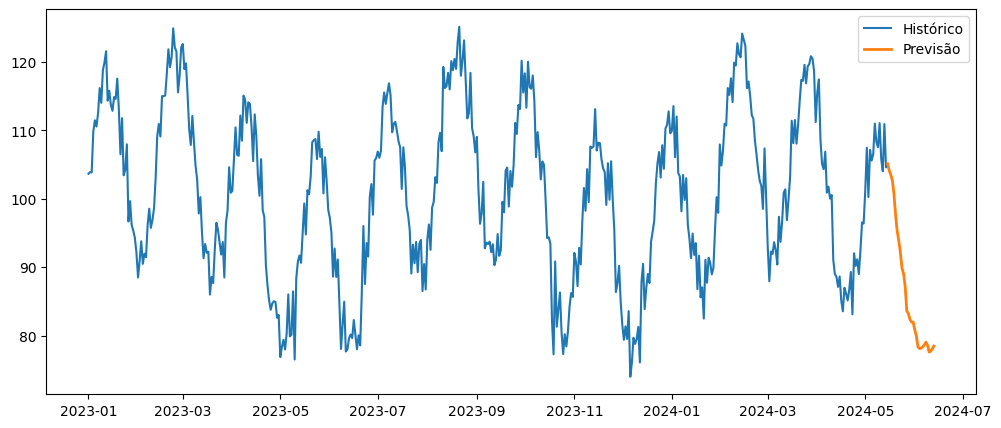

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(dados["Data"], dados["Valor"], label="Histórico")

plt.plot(
    previsoes["Data"],
    previsoes["Previsao"],
    label="Previsão",
    linewidth=2
)

plt.legend()
plt.show()